# Section 8: Quantum Algorithms

## Quatum teleportation

In [2]:
from qiskit import QuantumCircuit, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit import *
# from qiskit import Aer, *
from qiskit_aer import Aer, AerSimulator
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from math import pi
%matplotlib inline

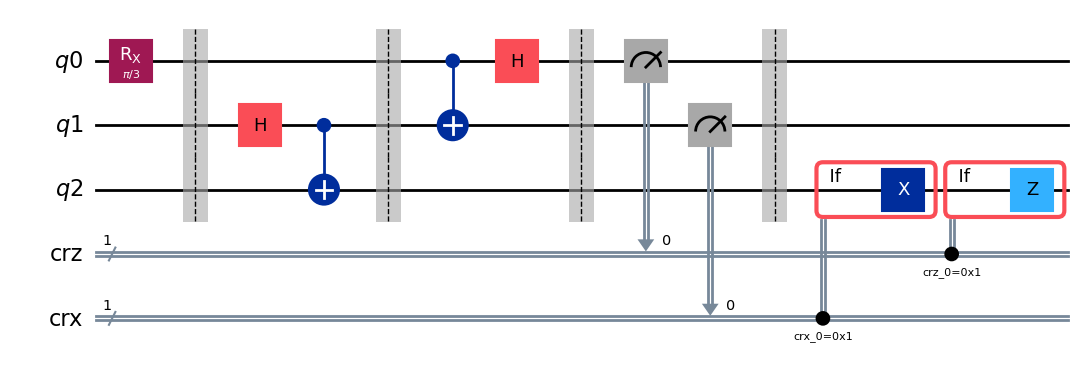

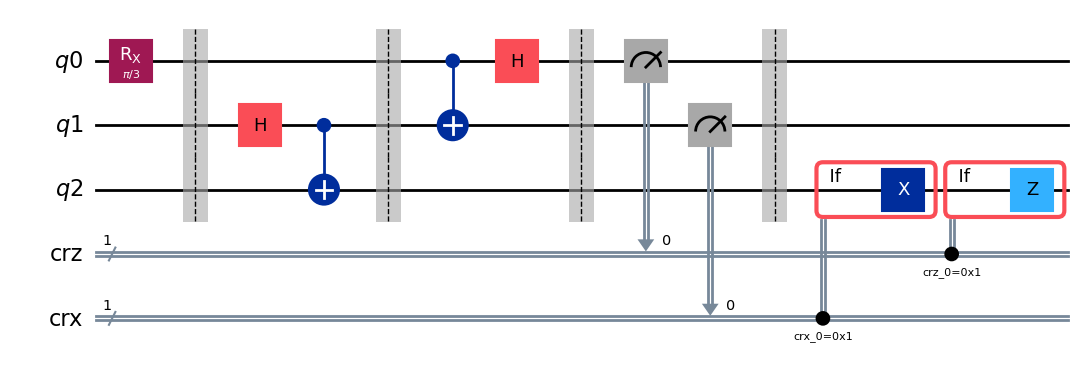

In [2]:
q0 = QuantumRegister(1, name='q0')
q1 = QuantumRegister(1, name='q1')
q2 = QuantumRegister(1, name='q2')

crz = ClassicalRegister(1, name='crz')
crx = ClassicalRegister(1, name='crx')

circuit = QuantumCircuit(q0, q1, q2, crz, crx)

circuit.rx(pi/3, q0)
circuit.barrier()

# Create Bell state pair
circuit.h(q1)
circuit.cx(q1, q2)
circuit.barrier()

# Perform Bell state measurement
circuit.cx(q0, q1)
circuit.h(q0)
circuit.barrier()
circuit.measure(q0, crz)
circuit.measure(q1, crx)
circuit.barrier()

# ...existing code...

# Replace:
# circuit.x(q2).c_if(crx, 1)
# circuit.z(q2).c_if(crz, 1)

with circuit.if_test((crx[0], True)):
    circuit.x(q2[0])

with circuit.if_test((crz[0], True)):
    circuit.z(q2[0])

# ...existing code...

circuit.draw(output='mpl')

### Using Qiskit's State Vector Simulator, to visualize the in-state of the 3 qubits

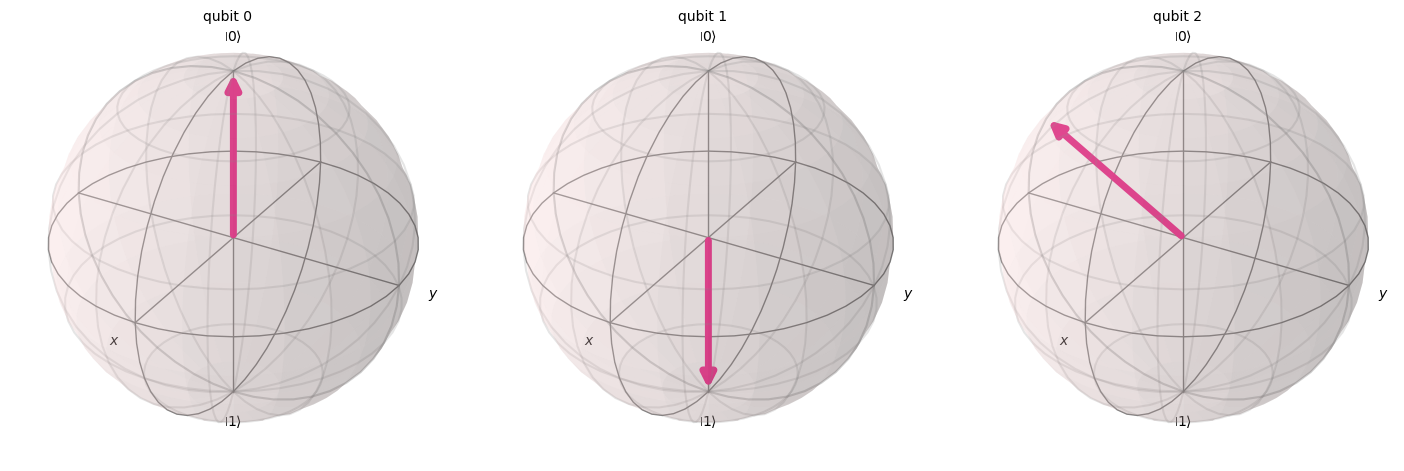

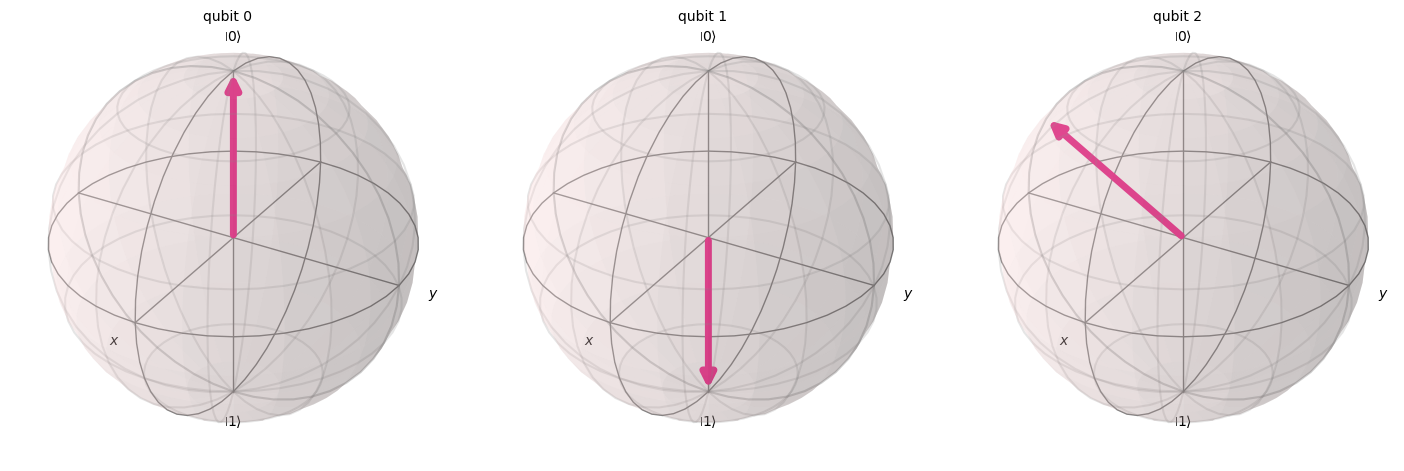

In [3]:
# 2. Instruct the circuit to save the statevector at this point
circuit.save_statevector()

# 3. Setup the AerSimulator to use the statevector method
simulator = AerSimulator(method='statevector')

# 4. Run the circuit and extract the result
result = simulator.run(circuits=circuit).result()
state_vector = result.get_statevector()
plot_bloch_multivector(state_vector)

### Used to measure the teleported quantum state

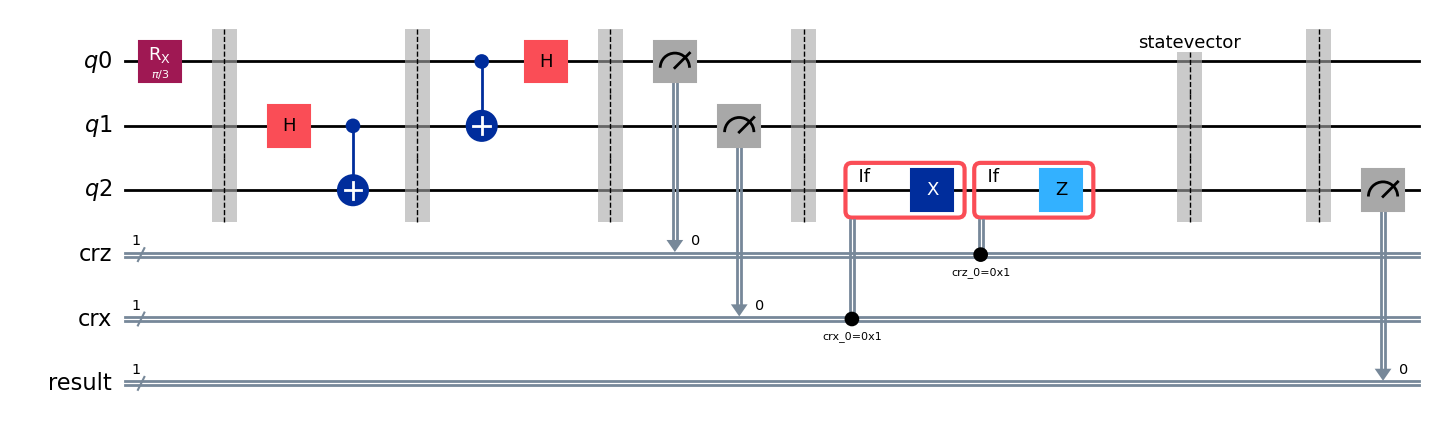

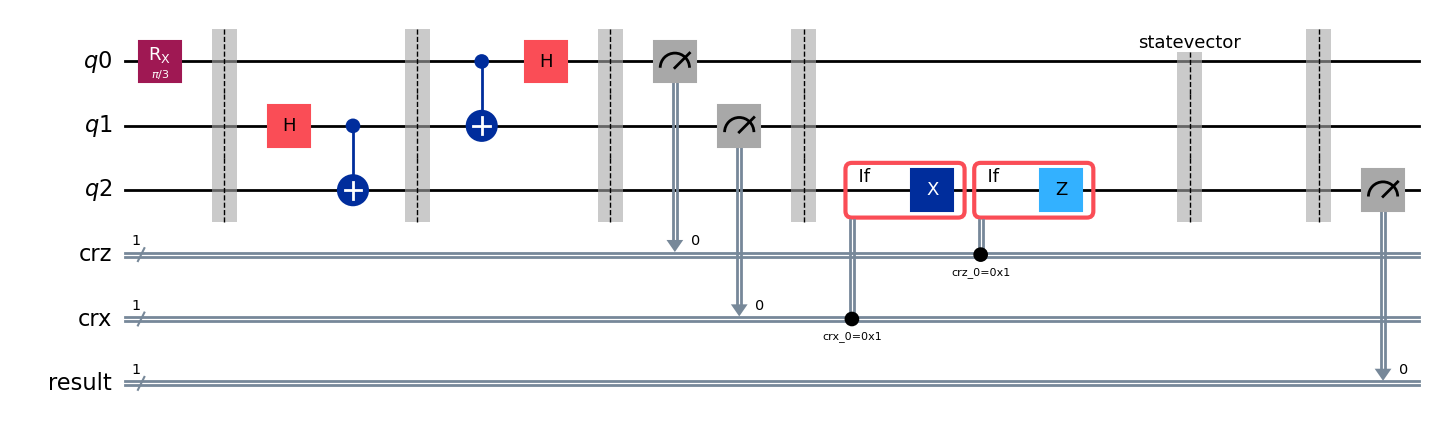

In [4]:
cr_result = ClassicalRegister(1, name='result')
circuit.barrier()
circuit.add_register(cr_result)
circuit.measure(2, 2)
circuit.draw(output='mpl')

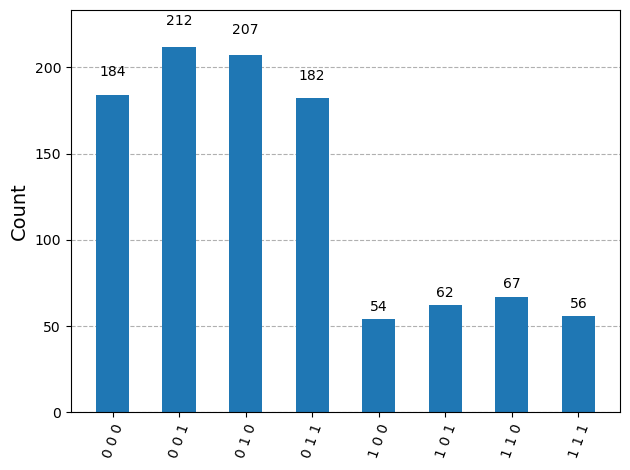

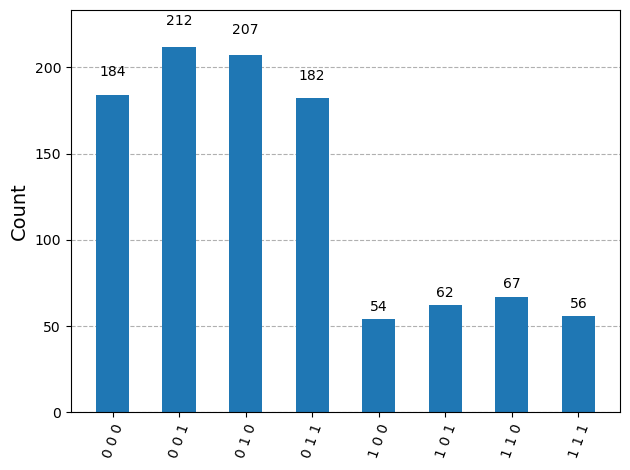

In [5]:
simulator = AerSimulator()
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit, shots=1024).result()
plot_histogram(result.get_counts())

## Section 2

### initialize qubit in the 1 (one) state

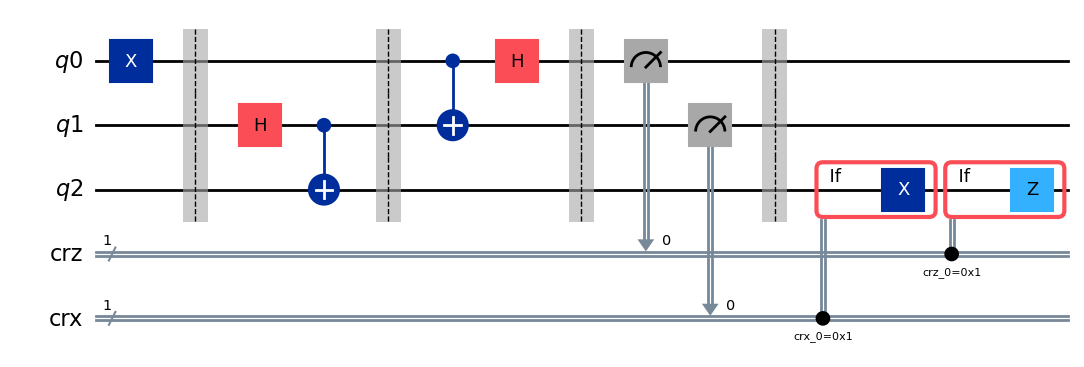

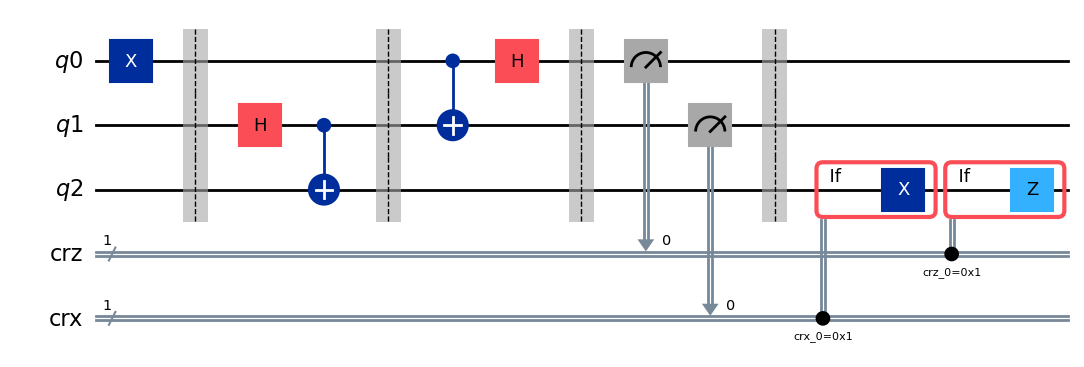

In [6]:
q0 = QuantumRegister(1, name='q0')
q1 = QuantumRegister(1, name='q1')
q2 = QuantumRegister(1, name='q2')

crz = ClassicalRegister(1, name='crz')
crx = ClassicalRegister(1, name='crx')

circuit = QuantumCircuit(q0, q1, q2, crz, crx)

circuit.x(0)
circuit.barrier()

# Create Bell state pair
circuit.h(q1)
circuit.cx(q1, q2)
circuit.barrier()

# Perform Bell state measurement
circuit.cx(q0, q1)
circuit.h(q0)
circuit.barrier()
circuit.measure(q0, crz)
circuit.measure(q1, crx)
circuit.barrier()

# ...existing code...

# Replace:
# circuit.x(q2).c_if(crx, 1)
# circuit.z(q2).c_if(crz, 1)

with circuit.if_test((crx[0], True)):
    circuit.x(q2[0])

with circuit.if_test((crz[0], True)):
    circuit.z(q2[0])

# ...existing code...

circuit.draw(output='mpl')

### Using Qiskit's State Vector Simulator, to visualize the in-state of the 3 qubits

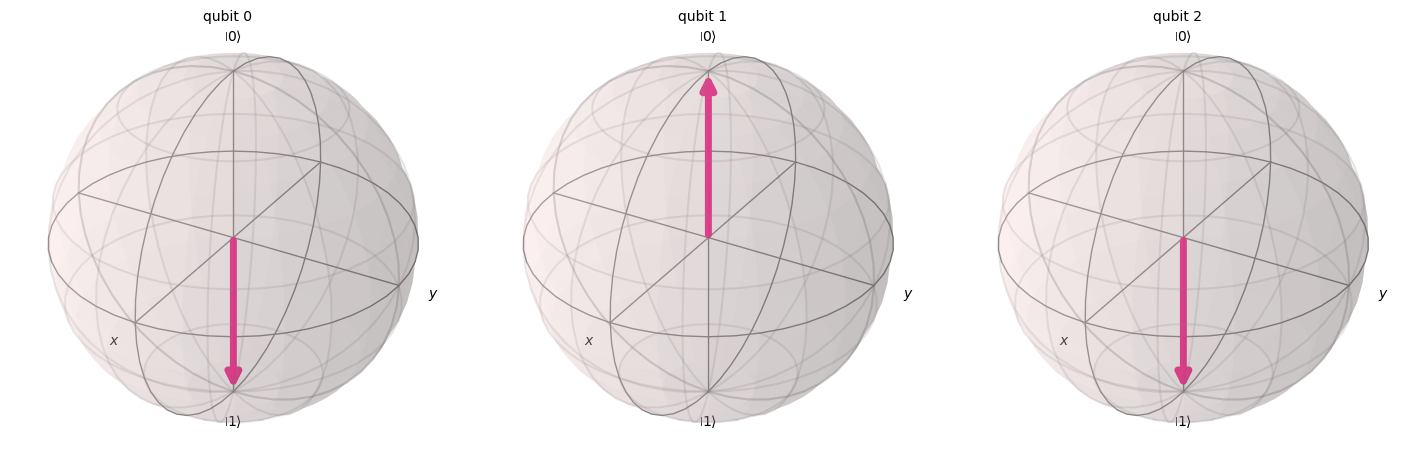

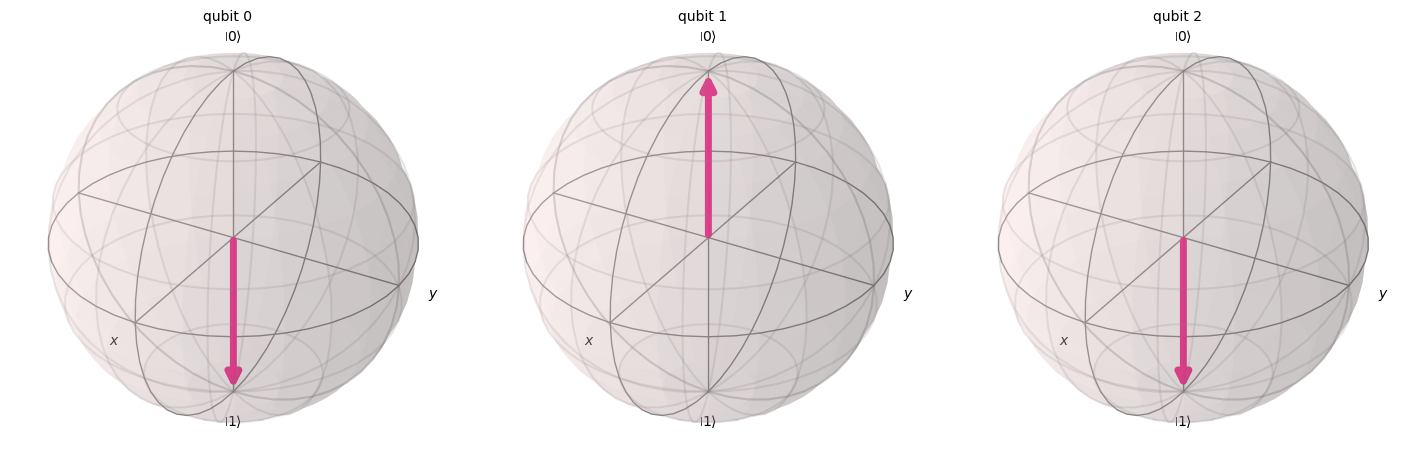

In [7]:
# 2. Instruct the circuit to save the statevector at this point
circuit.save_statevector()

# 3. Setup the AerSimulator to use the statevector method
simulator = AerSimulator(method='statevector')

# 4. Run the circuit and extract the result
result = simulator.run(circuits=circuit).result()
state_vector = result.get_statevector()
plot_bloch_multivector(state_vector)

### Used to measure the teleported quantum state

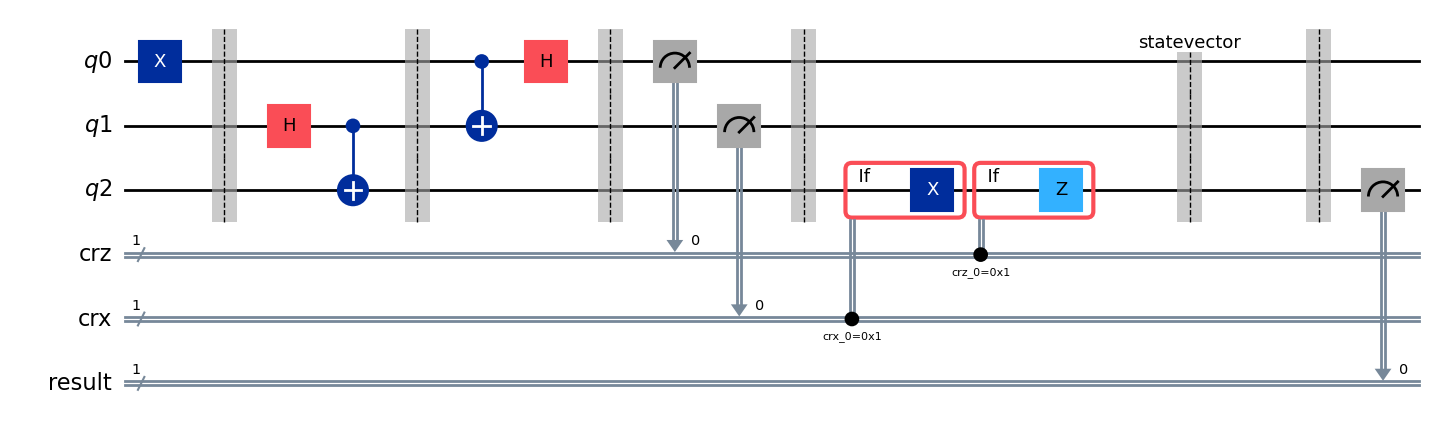

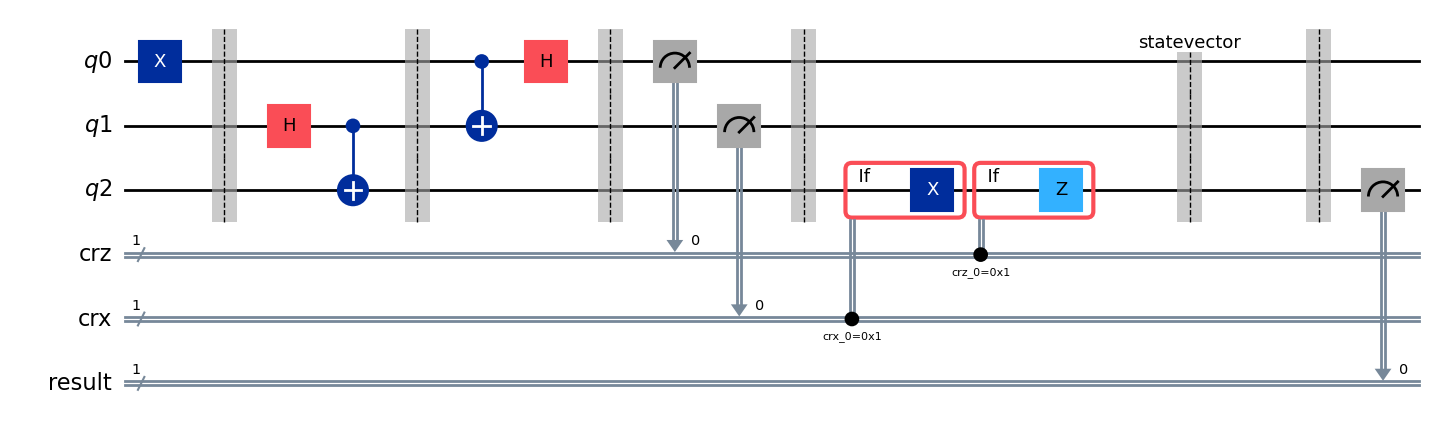

In [8]:
cr_result = ClassicalRegister(1, name='result')
circuit.barrier()
circuit.add_register(cr_result)
circuit.measure(2, 2)
circuit.draw(output='mpl')

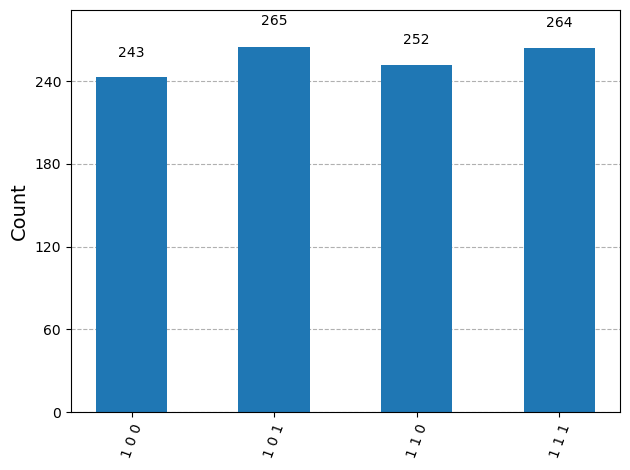

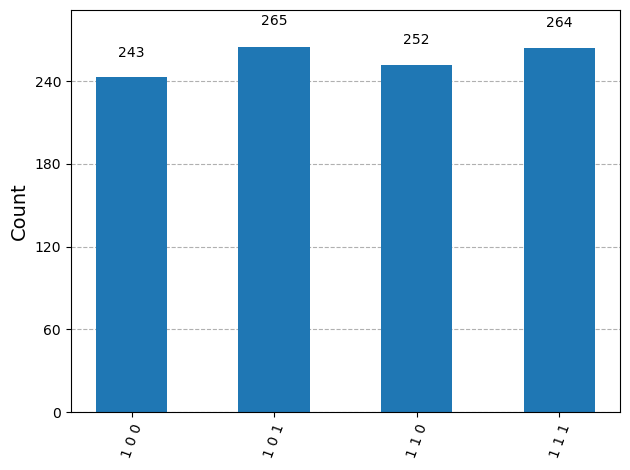

In [9]:
simulator = AerSimulator()
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit, shots=1024).result()
plot_histogram(result.get_counts())

## Section 3: Deferred Measurement(s)

### quantum teleportation circuit using deferred measurement

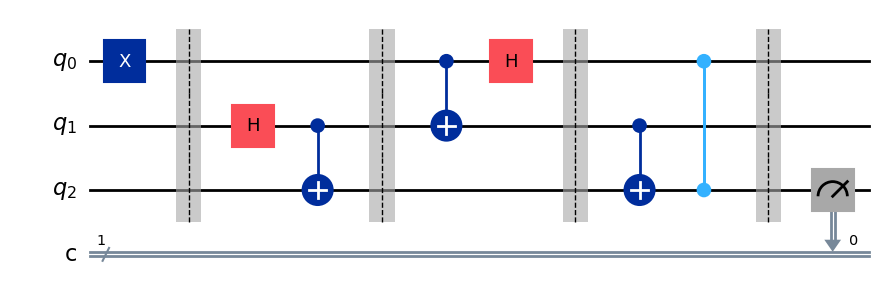

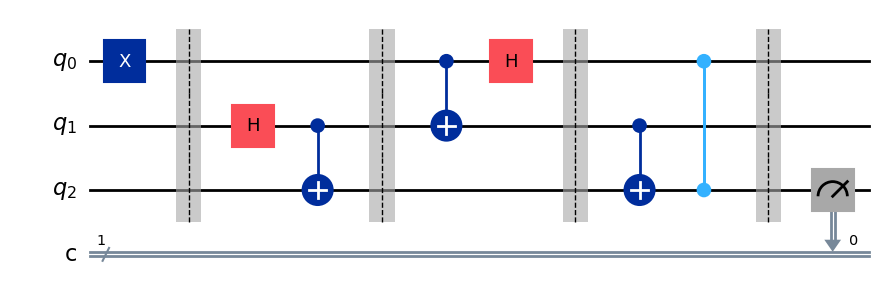

In [3]:
# quantum teleportation circuit using deferred measurement
circuit_def = QuantumCircuit(3, 1)

circuit_def.x(0)
circuit_def.barrier()

#create a Bell state pair
circuit_def.h(1)
circuit_def.cx(1, 2)
circuit_def.barrier()

circuit_def.cx(0, 1)
circuit_def.h(0)
circuit_def.barrier()

circuit_def.cx(1, 2)
circuit_def.cz(0, 2)
circuit_def.barrier()

circuit_def.measure(2, 0)

circuit_def.draw(output='mpl')

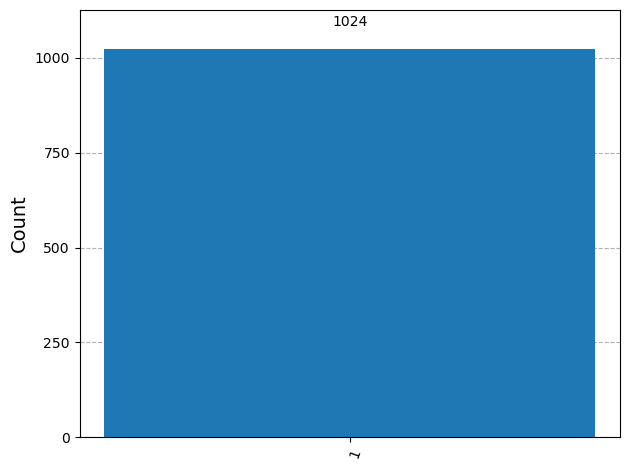

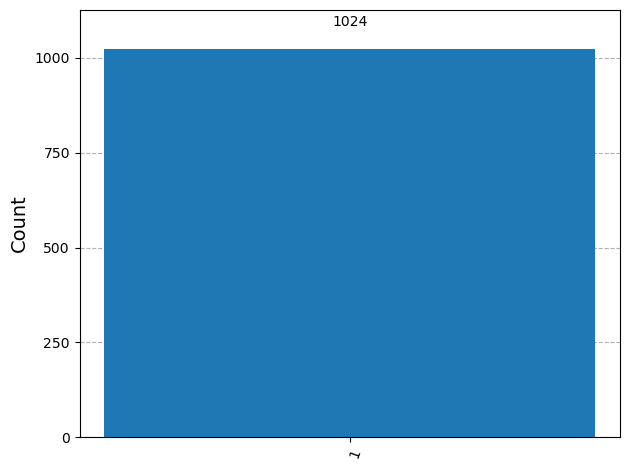

In [4]:
simulator = AerSimulator()
compiled_circuit = transpile(circuit_def, simulator)

result_def = simulator.run(compiled_circuit).result()
plot_histogram(result_def.get_counts())

## Section 3: Deferred Measurement

### quantum teleportation circuit using deferred measurement

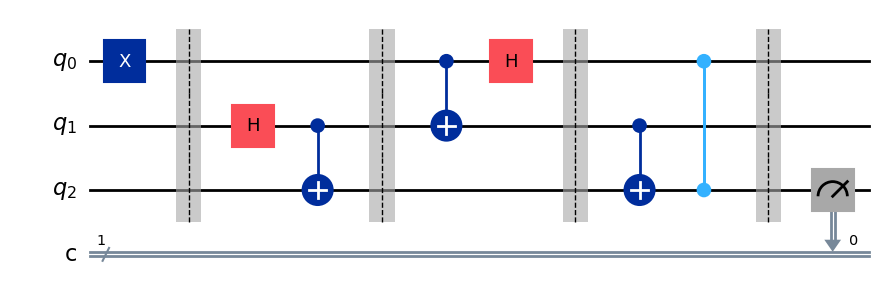

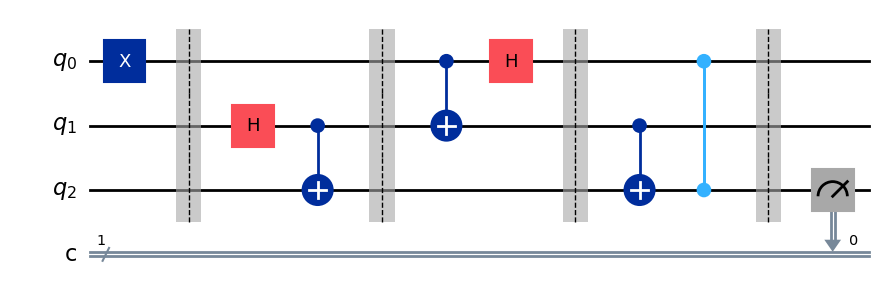

In [5]:
# quantum teleportation circuit using deferred measurement
circuit_def = QuantumCircuit(3, 1)

circuit_def.x(0)
circuit_def.barrier()

#create a Bell state pair
circuit_def.h(1)
circuit_def.cx(1, 2)
circuit_def.barrier()

circuit_def.cx(0, 1)
circuit_def.h(0)
circuit_def.barrier()

circuit_def.cx(1, 2)
circuit_def.cz(0, 2)
circuit_def.barrier()

circuit_def.measure(2, 0)

circuit_def.draw(output='mpl')

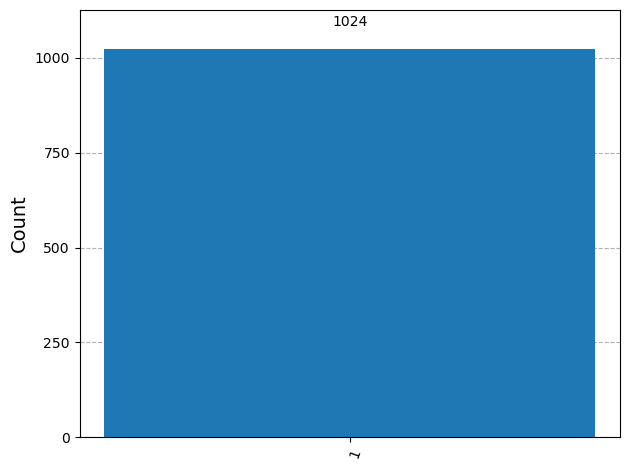

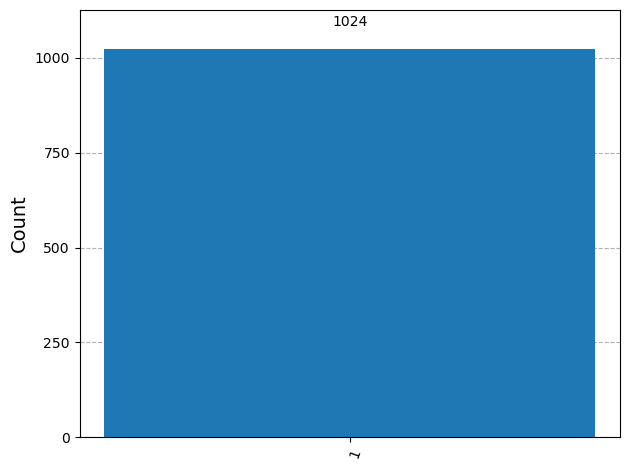

In [6]:
simulator = AerSimulator()
compiled_circuit = transpile(circuit_def, simulator)

result_def = simulator.run(compiled_circuit).result()
plot_histogram(result_def.get_counts())